In [71]:
import xarray as xr
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import scipy.stats as stats
from scipy.stats import weibull_min, linregress, norm
from scipy.special import gamma

In [72]:
DATA_DIR ='era5_out/'

ds_oper = xr.open_mfdataset(
    DATA_DIR + "era5_sl_*_oper.nc",
    combine="by_coords",
    engine="netcdf4"
)

ds_wave = xr.open_mfdataset(
    DATA_DIR + "era5_sl_*_wave.nc",
    combine="by_coords",
    engine="netcdf4"
)

ds = xr.merge([ds_oper, ds_wave])

/tmp/ipykernel_683855/702446443.py:15: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds_oper, ds_wave])
/tmp/ipykernel_683855/702446443.py:15: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds_oper, ds_wave])
/tmp/ipykernel_683855/702446443.py:15: FutureWarning: In a future version of xarray the default value fo

Buoy Positions

M1 : 53.1266°N 11.2000°W	 

M2 : 53.4800°N 05.4250°W	

M3 : 51.2166°N 10.5500°W

M4 : 55.0000°N 10.0000°W	

M5 : 51.6900°N 06.7040°W	

M6 : 53.0605°N 15.9300°W

In [73]:
# subset the years of interest
# ds = ds.sel(valid_time=slice("1974-01-01", "1979-12-31"))

In [84]:
with open(os.path.join("config.json"), "r") as f:
    config = json.load(f)
    
buoy_locations = config['buoys']

First buoy: M1 at (53.127°N, 11.200°W)


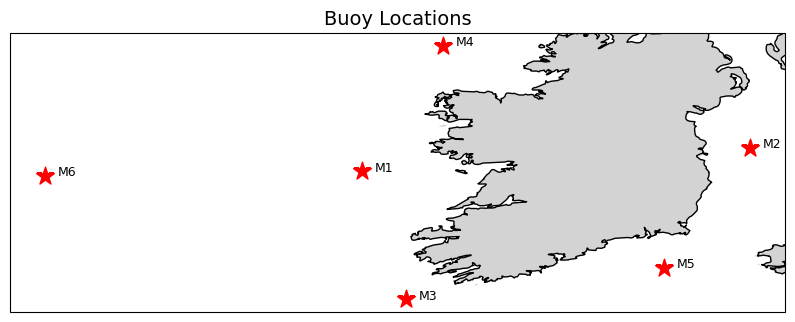

In [75]:
buoy_names = list(buoy_locations.keys())
buoy_lats = [buoy_locations[name]["latitude"] for name in buoy_names]
buoy_lons = [buoy_locations[name]["longitude"] for name in buoy_names]

def format_lat(lat):
    hemi = "N" if lat >= 0 else "S"
    return f"{abs(lat):.3f}°{hemi}"

def format_lon(lon):
    hemi = "E" if lon >= 0 else "W"
    return f"{abs(lon):.3f}°{hemi}"

print(
    f"First buoy: {buoy_names[0]} at "
    f"({format_lat(buoy_lats[0])}, {format_lon(buoy_lons[0])})"
)

fig = plt.figure(figsize=(10, 8), dpi=100, facecolor="white", edgecolor="black")
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
ax.scatter(
    buoy_lons,
    buoy_lats,
    color="red",
    marker="*",
    s=180,
    transform=ccrs.PlateCarree(),
)

# Annotate the buoys.
for name, lat, lon in zip(buoy_names, buoy_lats, buoy_lons):
    ax.text(lon + 0.19, lat + 0.0, name, transform=ccrs.PlateCarree(), fontsize=9)

ax.set_title("Buoy Locations", fontsize=14)
plt.show()

In [76]:
location_wise_data = {}

for buoy in buoy_locations:
    buoy_name, buoy_lat, buoy_lon = buoy, buoy_locations[buoy]['latitude'], buoy_locations[buoy]['longitude']

    ds_point = ds.sel(latitude=buoy_lat, longitude=buoy_lon, method='nearest')

    w10 = np.sqrt(ds_point["u10"]**2 + ds_point["v10"]**2)
    w100 = np.sqrt(ds_point["u100"]**2 + ds_point["v100"]**2)
    Hs, Tp, time = ds_point["swh"].values, ds_point["pp1d"].values, ds_point["valid_time"].values

    df = pd.DataFrame(
        {
            "time": time,
            "w10": w10,
            "w100": w100,
            "Hs": Hs,
            "Tp": Tp,
        }
    ).set_index("time")

    # All-sea-states approach (Johannesen): use every observation, not just storm peaks
    n_years = (df.index[-1] - df.index[0]).days / 365.25
    n_obs_per_year = len(df) / n_years
    beta = stats.norm.ppf(1 - 1 / (100 * n_obs_per_year))

    location_wise_data[buoy_name] = {
        "df": df,
        "beta": beta,
        "hs_peaks": df["Hs"].values,
        "tp_peaks": df["Tp"].values,
        "u10_peaks": df["w10"].values,
    }


In [77]:
# fig = plt.figure(figsize=(18, 10))
# colors=['blue', 'orange', 'green', 'red', 'purple', 'brown']
# i = 0
# for buoy_name, data in location_wise_data.items():
#     df = data["df"]
#     i += 1
#     ax = fig.add_subplot(2, 3, i, projection='3d')
#     ax.scatter(df["w10"], df["Hs"], df["Tp"], marker='o', alpha=0.005, color=colors[i-1])
#     ax.set_xlabel("w10 (m/s)")
#     ax.set_ylabel("Hs (m)")
#     ax.set_zlabel("Tp (s)")
#     ax.set_title(f"{buoy_name}: w10, Hs, Tp (ERA5)")

# plt.tight_layout()
# plt.show()

Fitting distributions

In [78]:
location_wise_data

{'M1': {'df':                            w10       w100        Hs        Tp
  time                                                         
  1950-01-01 00:00:00   9.036389  10.367843  2.027975  7.085793
  1950-01-01 01:00:00   8.901368  10.158443  1.917541  7.035500
  1950-01-01 02:00:00   8.893449  10.145606  1.831463  6.988136
  1950-01-01 03:00:00   8.539211   9.666479  1.750991  6.941261
  1950-01-01 04:00:00   9.217091  10.425894  1.703750  6.889503
  ...                        ...        ...       ...       ...
  2025-12-31 19:00:00  14.703668  18.020378  3.681417  8.389015
  2025-12-31 20:00:00  14.996935  18.467335  3.790456  8.482765
  2025-12-31 21:00:00  16.266478  20.076748  3.962450  8.552589
  2025-12-31 22:00:00  16.475937  20.212227  4.092724  8.746437
  2025-12-31 23:00:00  15.624244  18.816376  4.107593  8.996925
  
  [666216 rows x 4 columns],
  'beta': np.float64(4.726746304373306),
  'hs_peaks': array([2.027975 , 1.9175406, 1.8314629, ..., 3.96245  , 4.092724 ,
  

In [79]:
# Weibull and contour helper functions
def _weibull_mom_init(data):
    """Method-of-moments initial guess for Weibull shape and scale (loc=0)."""
    mu = np.mean(data)
    cv = np.std(data) / mu
    k0 = max(0.5, (1 / cv) ** 1.086)
    s0 = mu / gamma(1 + 1 / k0)
    return k0, s0

def fit_hs_weibull(hs_peaks, floc=0.0, show_plot=True):
    k0, s0 = _weibull_mom_init(hs_peaks[hs_peaks > floc] - floc)
    hs_shape, hs_loc, hs_scale = weibull_min.fit(hs_peaks, k0, floc=floc, scale=s0)

    print("Weibull parameters for Hs:")
    print(f"  shape (k):      {hs_shape:.4f}")
    print(f"  location:       {hs_loc:.4f}")
    print(f"  scale (lambda): {hs_scale:.4f}")
    print(f"  mean from fit:  {hs_loc + hs_scale * gamma(1 + 1 / hs_shape):.4f} m")

    if show_plot:
        x = np.linspace(floc, max(np.max(hs_peaks), floc + 8), 200)
        pdf_fitted = weibull_min.pdf(x, hs_shape, loc=hs_loc, scale=hs_scale)
        plt.figure(figsize=(8, 5))
        plt.hist(hs_peaks, bins=40, density=True, alpha=0.7, color="#4A6FA5", label="All sea states (observed)")
        plt.plot(x, pdf_fitted, color="red", linewidth=2, label="Weibull fit")
        plt.xlabel("Hs (m)")
        plt.ylabel("Density")
        plt.title("Hs - Weibull Fit (all sea states)")
        plt.legend()
        plt.show()

    return hs_shape, hs_loc, hs_scale

def fit_tp_weibull(
    hs_peaks, tp_peaks, hs_min=0.5, hs_max=12.0,
    bin_width=1.0, min_bin_count=10, show_plot=True,
    use_constant_std=True,
):
    hs_bins = np.arange(hs_min, hs_max + bin_width, bin_width)
    bin_centers, tp_means, tp_stds = [], [], []

    for i in range(len(hs_bins) - 1):
        mask = (hs_peaks >= hs_bins[i]) & (hs_peaks < hs_bins[i + 1])
        if mask.sum() > min_bin_count:
            bin_centers.append((hs_bins[i] + hs_bins[i + 1]) / 2)
            tp_means.append(np.mean(tp_peaks[mask]))
            tp_stds.append(np.std(tp_peaks[mask]))

    bin_centers = np.array(bin_centers)
    tp_means = np.array(tp_means)
    tp_stds = np.array(tp_stds)

    tp_b, tp_a, r, p, _ = linregress(bin_centers, tp_means)
    tp_std = float(np.mean(tp_stds)) if use_constant_std else tp_stds

    print("Conditional Tp model: mean Tp = a + b * Hs")
    print(f"  intercept (a): {tp_a:.4f}")
    print(f"  slope (b):     {tp_b:.4f}")
    print(f"  R^2:           {r**2:.4f}")
    print(f"  p-value:       {p:.4f}")
    print(f"  std(Tp):       {float(np.mean(tp_stds)):.4f} s (mean across Hs bins)")

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].scatter(hs_peaks, tp_peaks, alpha=0.3, s=10, color="#4A6FA5")
        axes[0].errorbar(bin_centers, tp_means, yerr=tp_stds, fmt="ro", capsize=5, label="Bin mean +- std")
        hs_line = np.linspace(hs_min, hs_max, 100)
        axes[0].plot(hs_line, tp_a + tp_b * hs_line, "r-", linewidth=2, label=f"Mean Tp fit (R^2={r**2:.2f})")
        axes[0].set_xlabel("Hs (m)")
        axes[0].set_ylabel("Tp (s)")
        axes[0].set_title("Tp vs Hs - All sea states")
        axes[0].legend()
        axes[1].plot(bin_centers, tp_stds, "go-", linewidth=2)
        axes[1].set_xlabel("Hs (m)")
        axes[1].set_ylabel("Std of Tp (s)")
        axes[1].set_title("Spread of Tp within each Hs bin")
        axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return tp_a, tp_b, tp_std, r**2, p

def fit_u10_weibull(hs_peaks, u10_peaks, floc=0.0, show_plot=True):
    k0, s0 = _weibull_mom_init(u10_peaks[u10_peaks > floc] - floc)
    u10_shape, u10_loc, u10_scale = weibull_min.fit(u10_peaks, k0, floc=floc, scale=s0)

    print("Weibull parameters for U10:")
    print(f"  shape (k):      {u10_shape:.4f}")
    print(f"  location:       {u10_loc:.4f}")
    print(f"  scale (lambda): {u10_scale:.4f}")
    print(f"  mean from fit:  {weibull_min.mean(u10_shape, loc=u10_loc, scale=u10_scale):.4f} m/s")
    print(f"  std from fit:   {weibull_min.std(u10_shape, loc=u10_loc, scale=u10_scale):.4f} m/s")

    if show_plot:
        x = np.linspace(floc, max(np.max(u10_peaks), floc + 12), 200)
        pdf_fitted = weibull_min.pdf(x, u10_shape, loc=u10_loc, scale=u10_scale)
        plt.figure(figsize=(8, 5))
        plt.hist(u10_peaks, bins=40, density=True, alpha=0.7, color="#4A6FA5", label="All sea states (observed)")
        plt.plot(x, pdf_fitted, color="red", linewidth=2, label="Weibull fit")
        plt.xlabel("U10 (m/s)")
        plt.ylabel("Density")
        plt.title("U10 - Weibull Fit (all sea states)")
        plt.legend()
        plt.show()

    return u10_shape, u10_loc, u10_scale

def generate_environmental_contour(
    beta, hs_params, tp_params, u10_params, n=100, clip_eps=1e-6
):
    hs_shape, hs_loc, hs_scale = hs_params
    tp_a, tp_b, tp_std = tp_params
    u10_shape, u10_loc, u10_scale = u10_params

    phi = np.linspace(0, np.pi, n)
    theta = np.linspace(0, 2 * np.pi, n)
    PHI, THETA = np.meshgrid(phi, theta)

    u1 = beta * np.sin(PHI) * np.cos(THETA)
    u2 = beta * np.sin(PHI) * np.sin(THETA)
    u3 = beta * np.cos(PHI)

    p1 = np.clip(norm.cdf(u1), clip_eps, 1 - clip_eps)
    p2 = np.clip(norm.cdf(u2), clip_eps, 1 - clip_eps)
    p3 = np.clip(norm.cdf(u3), clip_eps, 1 - clip_eps)

    Hs_contour = weibull_min.ppf(p1, hs_shape, loc=hs_loc, scale=hs_scale)
    tp_mean_contour = tp_a + tp_b * Hs_contour
    Tp_contour = norm.ppf(p2, loc=tp_mean_contour, scale=float(tp_std))
    U10_contour = weibull_min.ppf(p3, u10_shape, loc=u10_loc, scale=u10_scale)

    return {
        "PHI": PHI, "THETA": THETA,
        "u1": u1, "u2": u2, "u3": u3,
        "Hs_contour": Hs_contour,
        "Tp_contour": Tp_contour,
        "U10_contour": U10_contour,
    }

def plot_contour_projections(Hs_contour, Tp_contour, U10_contour, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].scatter(Hs_contour.flatten(), Tp_contour.flatten(), s=1, alpha=0.3, color="#4A6FA5")
    axes[0].set_xlabel("Hs (m)")
    axes[0].set_ylabel("Tp (s)")
    axes[0].set_title("Contour: Hs vs Tp")
    axes[0].grid(alpha=0.3)
    axes[1].scatter(Hs_contour.flatten(), U10_contour.flatten(), s=1, alpha=0.3, color="#4A6FA5")
    axes[1].set_xlabel("Hs (m)")
    axes[1].set_ylabel("U10 (m/s)")
    axes[1].set_title("Contour: Hs vs U10")
    axes[1].grid(alpha=0.3)
    axes[2].scatter(Tp_contour.flatten(), U10_contour.flatten(), s=1, alpha=0.3, color="#4A6FA5")
    axes[2].set_xlabel("Tp (s)")
    axes[2].set_ylabel("U10 (m/s)")
    axes[2].set_title("Contour: Tp vs U10")
    axes[2].grid(alpha=0.3)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()



=== Distribution plots: M1 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


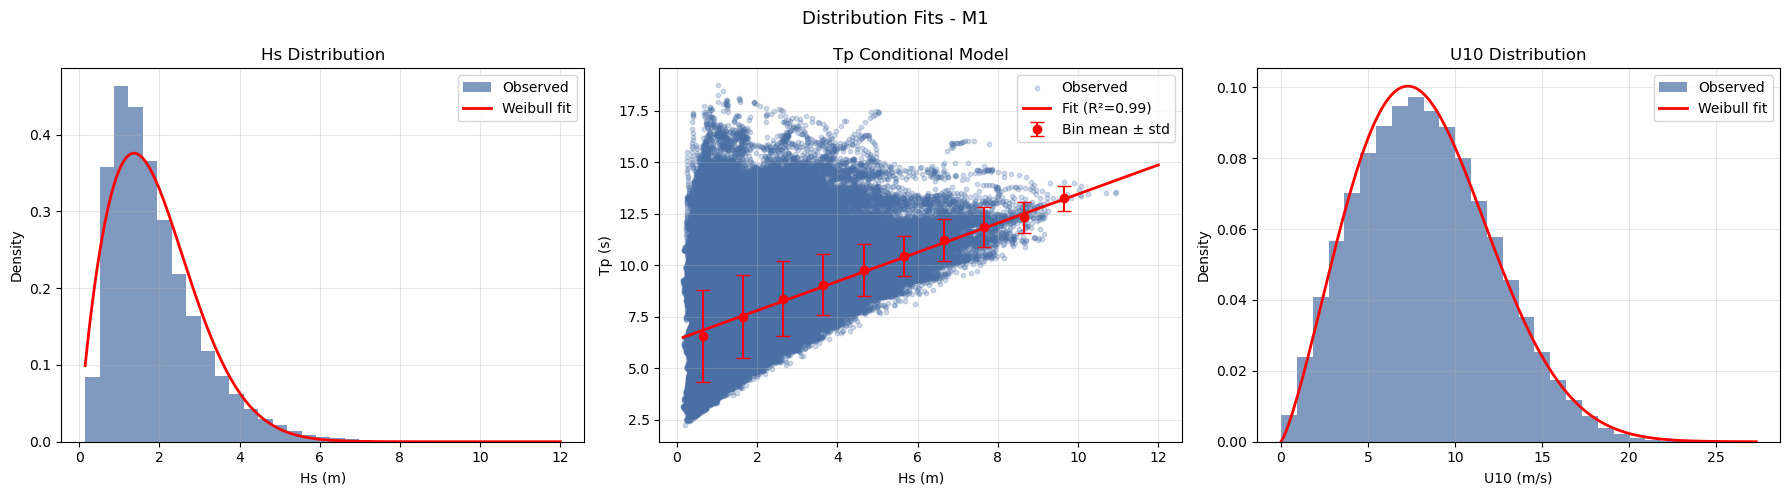


=== Distribution plots: M2 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


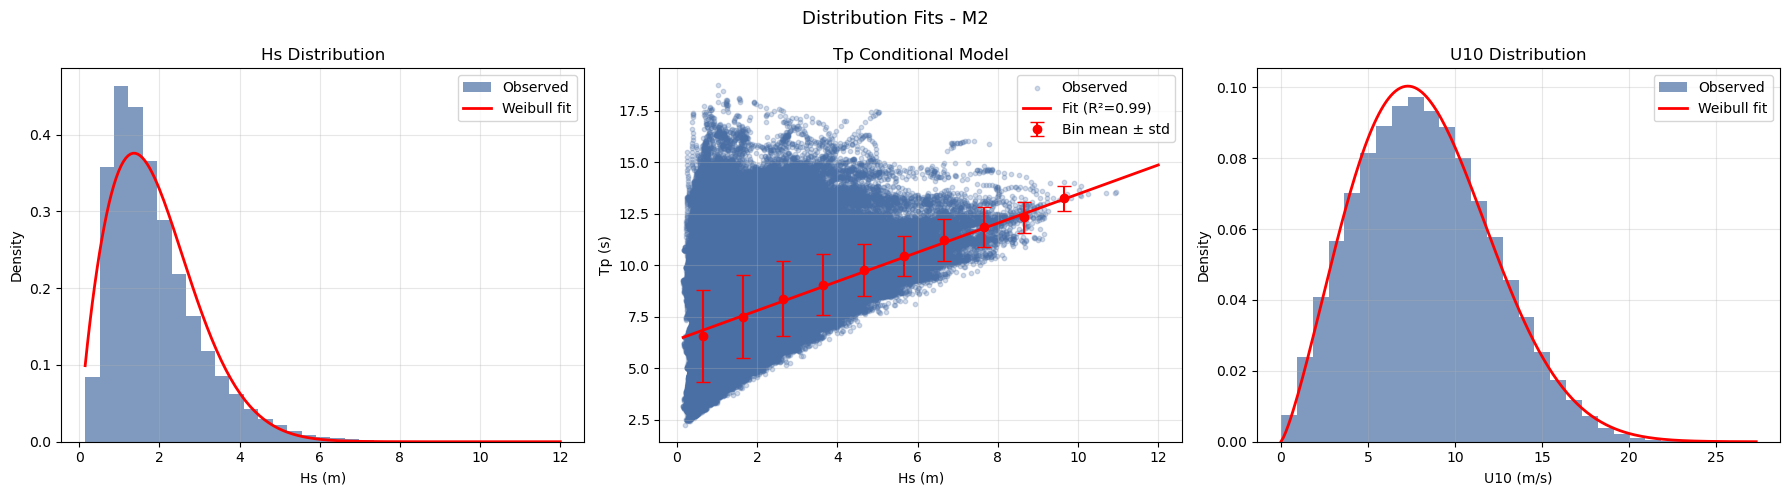


=== Distribution plots: M3 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


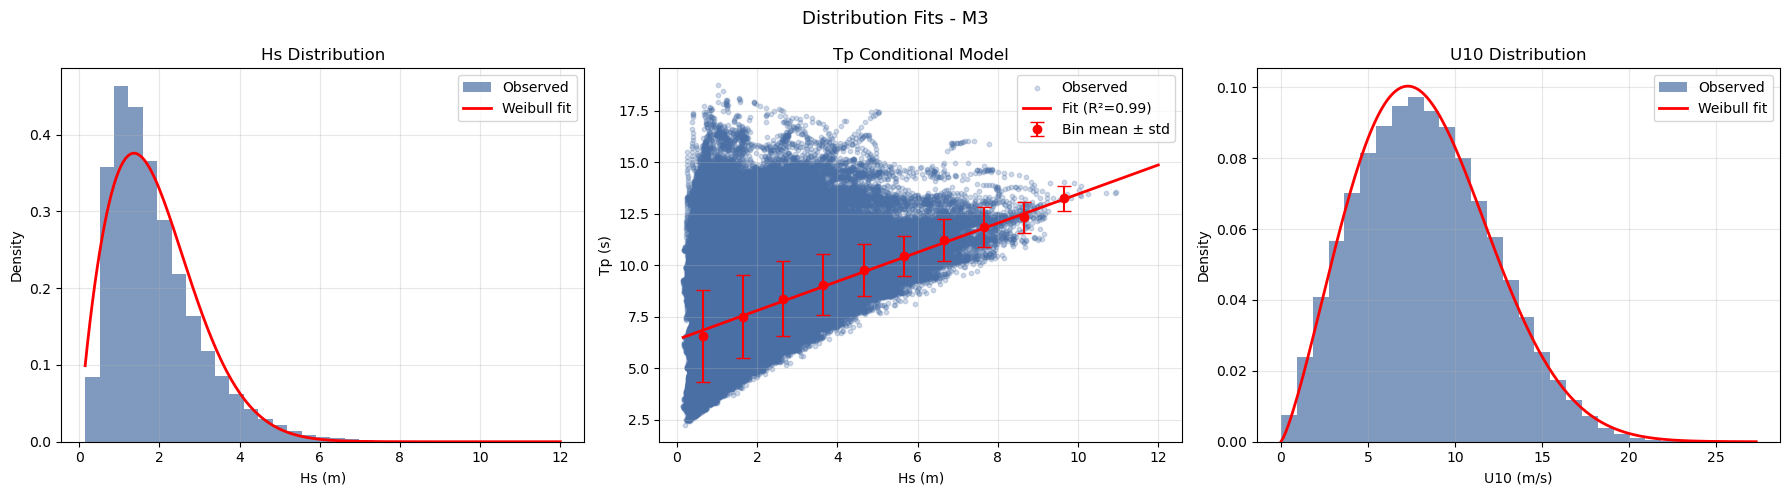


=== Distribution plots: M4 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


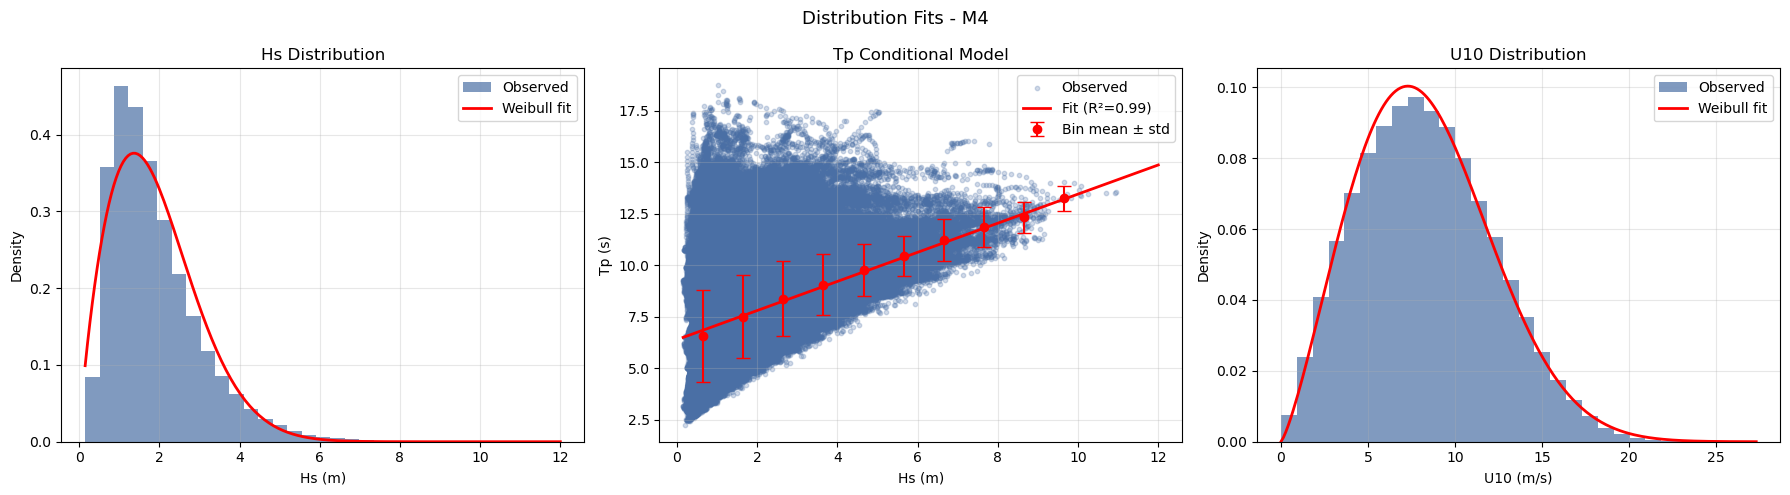


=== Distribution plots: M5 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


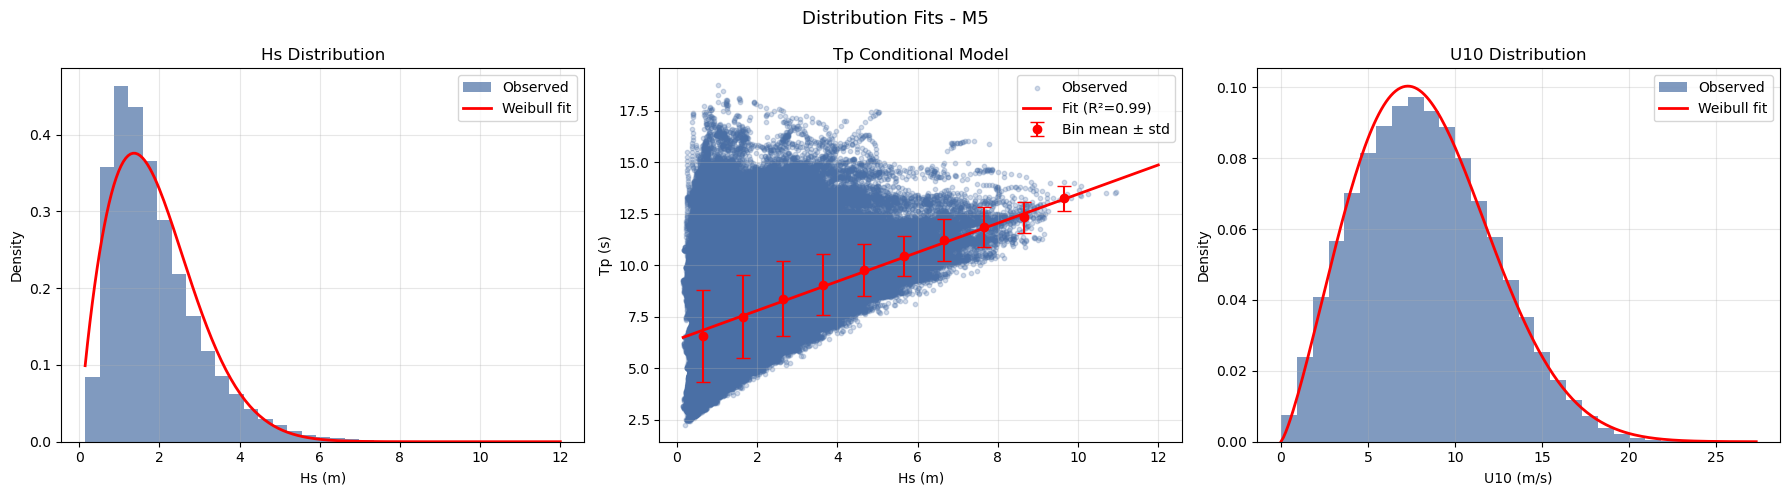


=== Distribution plots: M6 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


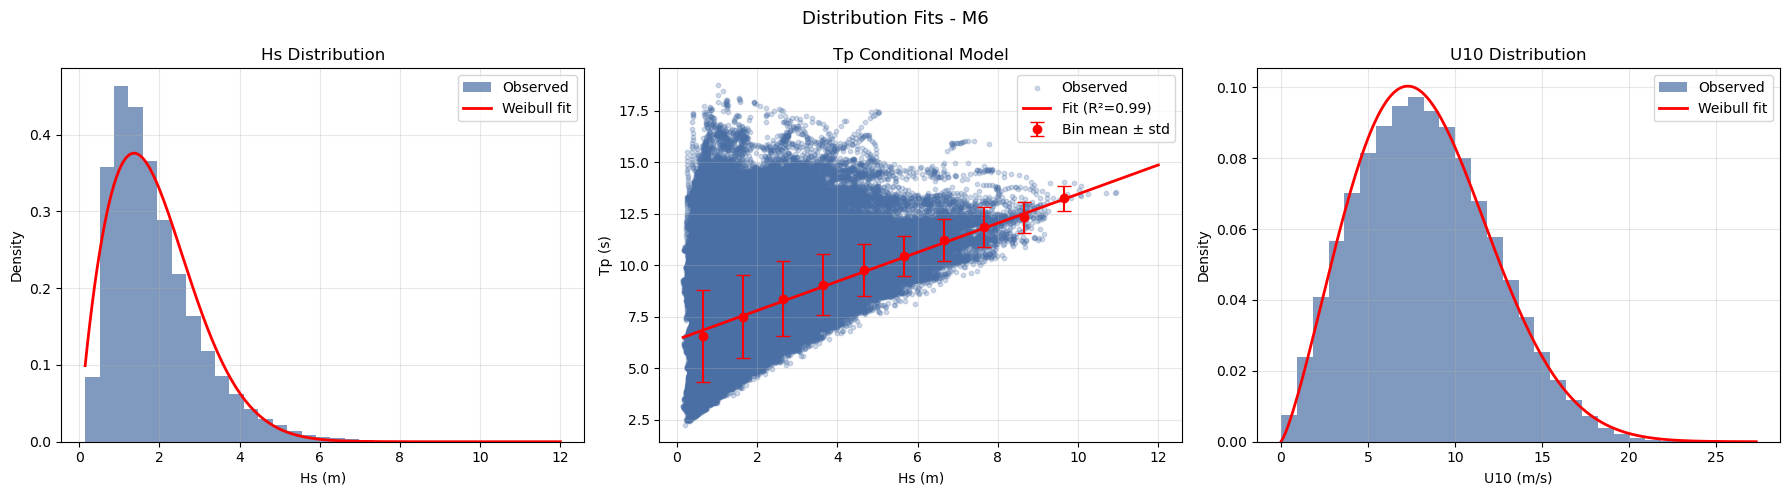


Completed distribution diagnostic plots for all buoys.


{'M1': {'beta': np.float64(4.726746304373306),
  'hs_shape': np.float32(1.8040003),
  'hs_loc': 0.0,
  'hs_scale': np.float32(2.143941),
  'tp_a': np.float64(6.383388823933072),
  'tp_b': np.float64(0.706454618771871),
  'tp_std': 1.3334426879882812,
  'tp_r2': np.float64(0.994534662049847),
  'tp_p': np.float64(3.519790481848839e-09),
  'u10_shape': np.float32(2.2833686),
  'u10_loc': 0.0,
  'u10_scale': np.float32(9.38697)},
 'M2': {'beta': np.float64(4.726746304373306),
  'hs_shape': np.float32(1.8040003),
  'hs_loc': 0.0,
  'hs_scale': np.float32(2.143941),
  'tp_a': np.float64(6.383388823933072),
  'tp_b': np.float64(0.706454618771871),
  'tp_std': 1.3334426879882812,
  'tp_r2': np.float64(0.994534662049847),
  'tp_p': np.float64(3.519790481848839e-09),
  'u10_shape': np.float32(2.2833686),
  'u10_loc': 0.0,
  'u10_scale': np.float32(9.38697)},
 'M3': {'beta': np.float64(4.726746304373306),
  'hs_shape': np.float32(1.8040003),
  'hs_loc': 0.0,
  'hs_scale': np.float32(2.143941),
 

In [82]:
fitted_params_by_buoy = {}

for buoy_name, data in location_wise_data.items():
    print(f"\n=== Distribution plots: {buoy_name} ===")
    hs_peaks = data["hs_peaks"]
    tp_peaks = data["tp_peaks"]
    u10_peaks = data["u10_peaks"]
    beta = data["beta"]

    # Fit without internal plotting so we can build one 1x3 subplot figure
    hs_shape, hs_loc, hs_scale = fit_hs_weibull(hs_peaks, show_plot=False)
    tp_a, tp_b, tp_std, tp_r2, tp_p = fit_tp_weibull(hs_peaks, tp_peaks, show_plot=False)
    u10_shape, u10_loc, u10_scale = fit_u10_weibull(hs_peaks, u10_peaks, show_plot=False)

    fitted_params_by_buoy[buoy_name] = {
        "beta": beta,
        "hs_shape": hs_shape,
        "hs_loc": hs_loc,
        "hs_scale": hs_scale,
        "tp_a": tp_a,
        "tp_b": tp_b,
        "tp_std": float(tp_std),
        "tp_r2": tp_r2,
        "tp_p": tp_p,
        "u10_shape": u10_shape,
        "u10_loc": u10_loc,
        "u10_scale": u10_scale,
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1) Hs distribution
    hs_x = np.linspace(min(np.min(hs_peaks), 4.0), max(np.max(hs_peaks), 12.0), 200)
    hs_pdf = weibull_min.pdf(hs_x, hs_shape, loc=hs_loc, scale=hs_scale)
    axes[0].hist(hs_peaks, bins=30, density=True, alpha=0.7, color="#4A6FA5", label="Observed")
    axes[0].plot(hs_x, hs_pdf, color="red", linewidth=2, label="Weibull fit")
    axes[0].set_xlabel("Hs (m)")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Hs Distribution")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # 2) Tp conditional model
    hs_bins = np.arange(min(np.min(hs_peaks), 4.0), max(np.max(hs_peaks), 12.0) + 1.0, 1.0)
    bin_centers, tp_means, tp_stds = [], [], []
    for i in range(len(hs_bins) - 1):
        mask = (hs_peaks >= hs_bins[i]) & (hs_peaks < hs_bins[i + 1])
        if mask.sum() > 10:
            bin_centers.append((hs_bins[i] + hs_bins[i + 1]) / 2)
            tp_means.append(np.mean(tp_peaks[mask]))
            tp_stds.append(np.std(tp_peaks[mask]))

    bin_centers = np.array(bin_centers)
    tp_means = np.array(tp_means)
    tp_stds = np.array(tp_stds)

    axes[1].scatter(hs_peaks, tp_peaks, alpha=0.25, s=10, color="#4A6FA5", label="Observed")
    if len(bin_centers) > 0:
        axes[1].errorbar(bin_centers, tp_means, yerr=tp_stds, fmt="ro", capsize=5, label="Bin mean ± std")
    hs_line = np.linspace(min(np.min(hs_peaks), 4.0), max(np.max(hs_peaks), 12.0), 100)
    axes[1].plot(hs_line, tp_a + tp_b * hs_line, "r-", linewidth=2, label=f"Fit (R²={tp_r2:.2f})")
    axes[1].set_xlabel("Hs (m)")
    axes[1].set_ylabel("Tp (s)")
    axes[1].set_title("Tp Conditional Model")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # 3) U10 distribution
    u10_x = np.linspace(min(np.min(u10_peaks), 15.0), max(np.max(u10_peaks), 27.0), 200)
    u10_pdf = weibull_min.pdf(u10_x, u10_shape, loc=u10_loc, scale=u10_scale)
    axes[2].hist(u10_peaks, bins=30, density=True, alpha=0.7, color="#4A6FA5", label="Observed")
    axes[2].plot(u10_x, u10_pdf, color="red", linewidth=2, label="Weibull fit")
    axes[2].set_xlabel("U10 (m/s)")
    axes[2].set_ylabel("Density")
    axes[2].set_title("U10 Distribution")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.suptitle(f"Distribution Fits - {buoy_name}", fontsize=13)
    plt.tight_layout()
    plt.show()

print("\nCompleted distribution diagnostic plots for all buoys.")
fitted_params_by_buoy

=== M1 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


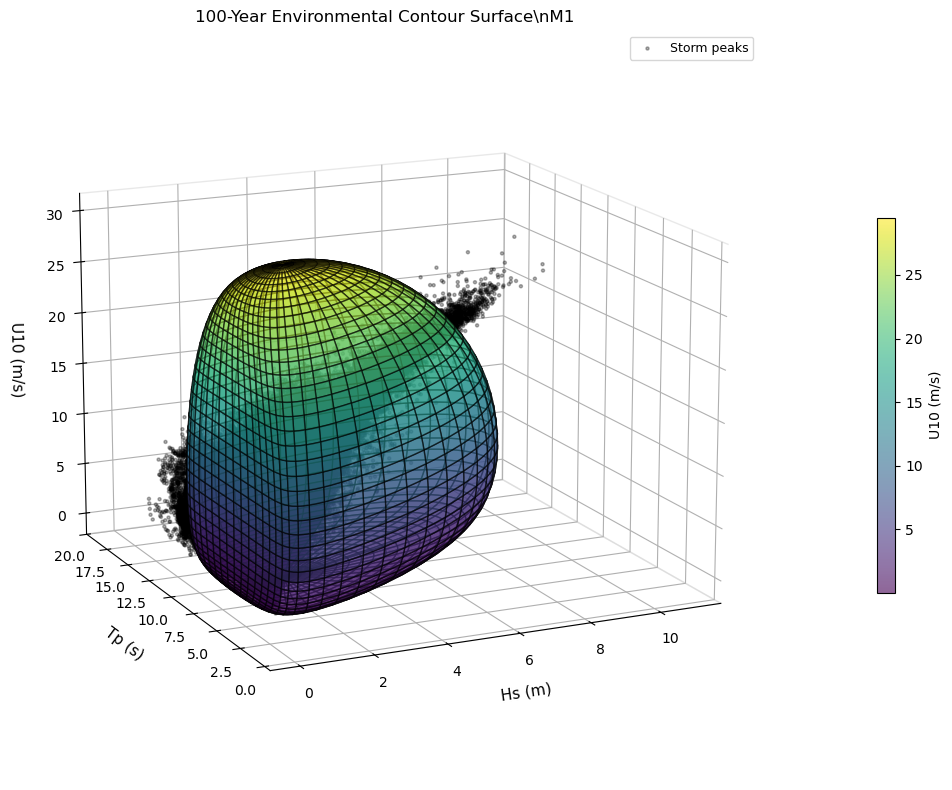

=== M2 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


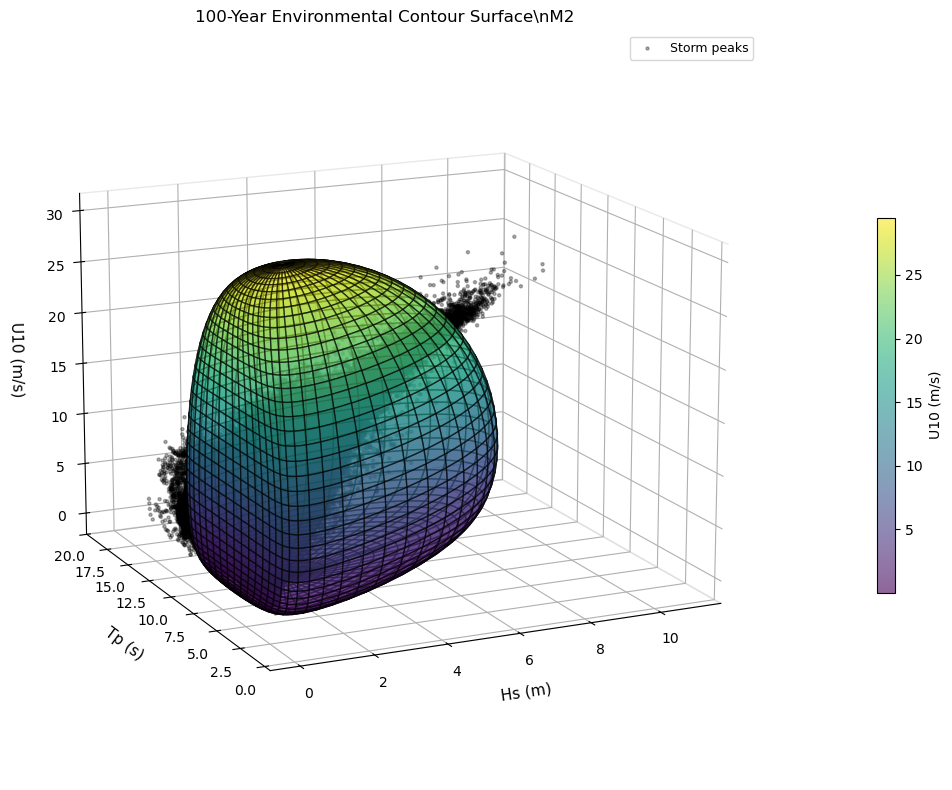

=== M3 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


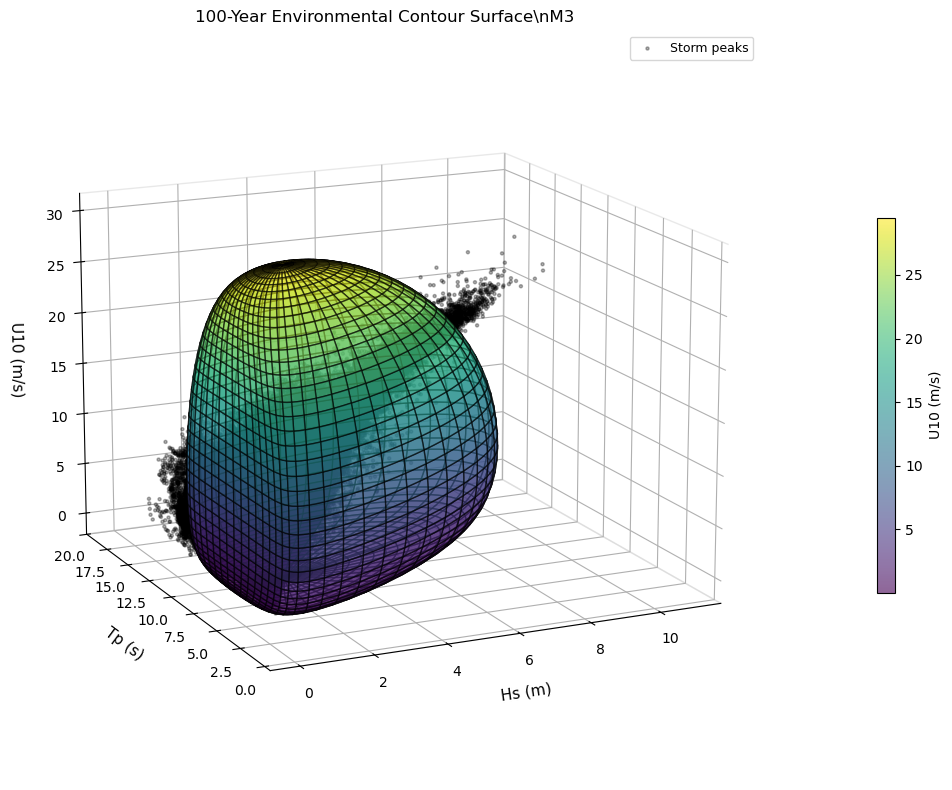

=== M4 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


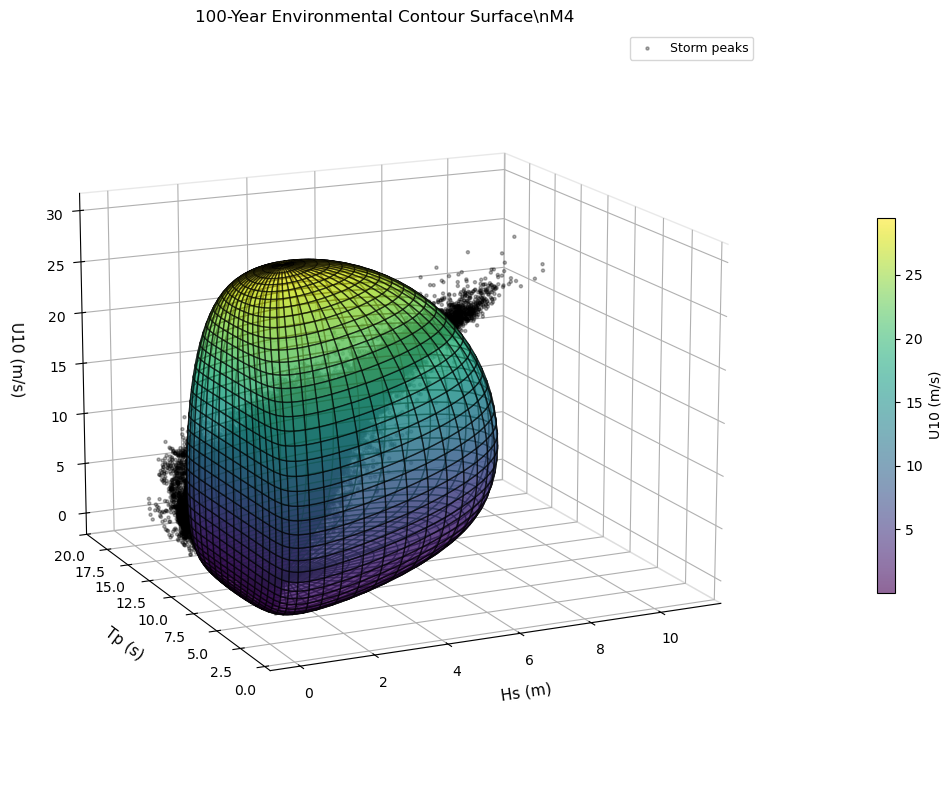

=== M5 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


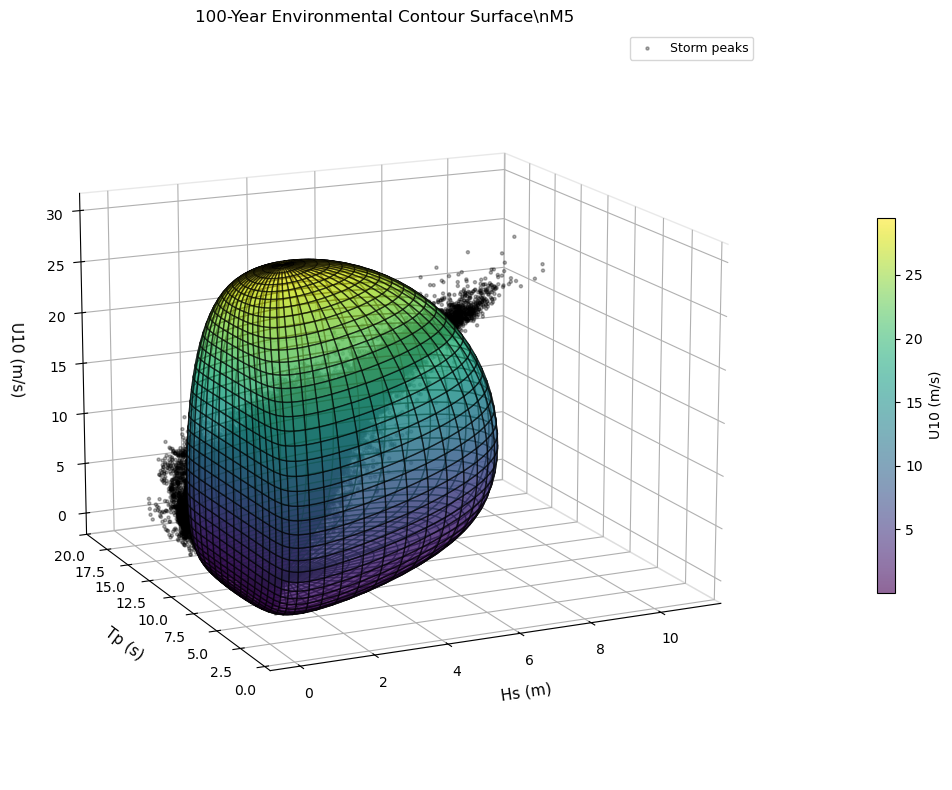

=== M6 ===
Weibull parameters for Hs:
  shape (k):      1.8040
  location:       0.0000
  scale (lambda): 2.1439
  mean from fit:  1.9064 m
Conditional Tp model: mean Tp = a + b * Hs
  intercept (a): 6.3834
  slope (b):     0.7065
  R^2:           0.9945
  p-value:       0.0000
  std(Tp):       1.3334 s (mean across Hs bins)
Weibull parameters for U10:
  shape (k):      2.2834
  location:       0.0000
  scale (lambda): 9.3870
  mean from fit:  8.3154 m/s
  std from fit:   3.8591 m/s


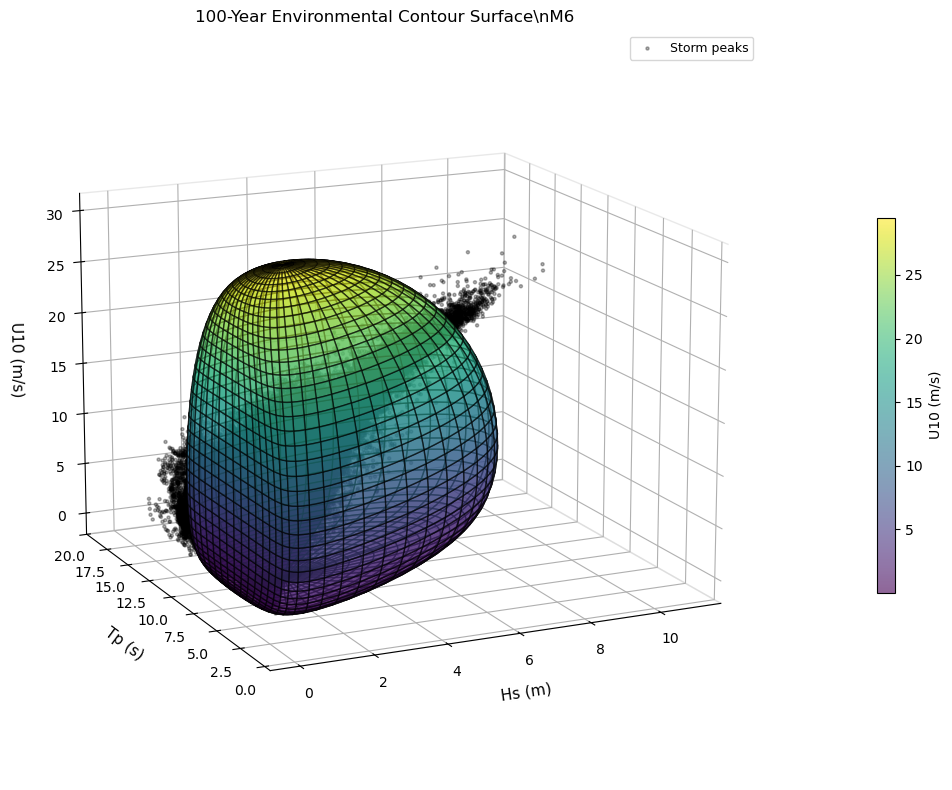


Fitted contour-ready parameters by buoy:


{'M1': {'beta': np.float64(4.726746304373306),
  'hs_shape': np.float32(1.8040003),
  'hs_loc': 0.0,
  'hs_scale': np.float32(2.143941),
  'tp_a': np.float64(6.383388823933072),
  'tp_b': np.float64(0.706454618771871),
  'tp_std': 1.3334426879882812,
  'tp_r2': np.float64(0.994534662049847),
  'tp_p': np.float64(3.519790481848839e-09),
  'u10_shape': np.float32(2.2833686),
  'u10_loc': 0.0,
  'u10_scale': np.float32(9.38697)},
 'M2': {'beta': np.float64(4.726746304373306),
  'hs_shape': np.float32(1.8040003),
  'hs_loc': 0.0,
  'hs_scale': np.float32(2.143941),
  'tp_a': np.float64(6.383388823933072),
  'tp_b': np.float64(0.706454618771871),
  'tp_std': 1.3334426879882812,
  'tp_r2': np.float64(0.994534662049847),
  'tp_p': np.float64(3.519790481848839e-09),
  'u10_shape': np.float32(2.2833686),
  'u10_loc': 0.0,
  'u10_scale': np.float32(9.38697)},
 'M3': {'beta': np.float64(4.726746304373306),
  'hs_shape': np.float32(1.8040003),
  'hs_loc': 0.0,
  'hs_scale': np.float32(2.143941),
 

In [83]:
fitted_params_by_buoy = {}

for buoy_name, data in location_wise_data.items():
    print(f"=== {buoy_name} ===")
    hs_peaks = data["hs_peaks"]
    tp_peaks = data["tp_peaks"]
    u10_peaks = data["u10_peaks"]
    beta = data["beta"]

    # Fit distributions/models for this buoy.
    hs_shape, hs_loc, hs_scale = fit_hs_weibull(hs_peaks, show_plot=False)
    tp_a, tp_b, tp_std, tp_r2, tp_p = fit_tp_weibull(
        hs_peaks, tp_peaks, show_plot=False
    )
    u10_shape, u10_loc, u10_scale = fit_u10_weibull(
        hs_peaks, u10_peaks, show_plot=False
    )

    fitted_params_by_buoy[buoy_name] = {
        "beta": beta,
        "hs_shape": hs_shape,
        "hs_loc": hs_loc,
        "hs_scale": hs_scale,
        "tp_a": tp_a,
        "tp_b": tp_b,
        "tp_std": float(tp_std),
        "tp_r2": tp_r2,
        "tp_p": tp_p,
        "u10_shape": u10_shape,
        "u10_loc": u10_loc,
        "u10_scale": u10_scale,
    }

    # Build 100-year contour surface for this buoy.
    contour = generate_environmental_contour(
        beta=beta,
        hs_params=(hs_shape, hs_loc, hs_scale),
        tp_params=(tp_a, tp_b, float(tp_std)),
        u10_params=(u10_shape, u10_loc, u10_scale),
        n=100,
        clip_eps=1e-6,
    )

    Hs_contour = contour["Hs_contour"]
    Tp_contour = contour["Tp_contour"]
    U10_contour = contour["U10_contour"]

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        Hs_contour,
        Tp_contour,
        U10_contour,
        cmap="viridis",
        alpha=0.6,
        edgecolor="k",
    )

    ax.scatter(
        hs_peaks,
        tp_peaks,
        u10_peaks,
        color="black",
        s=5,
        alpha=0.3,
        label="Storm peaks",
    )

    ax.set_xlabel("Hs (m)", fontsize=11, labelpad=10)
    ax.set_ylabel("Tp (s)", fontsize=11, labelpad=10)
    ax.set_zlabel("U10 (m/s)", fontsize=11, labelpad=10)
    ax.set_title(
        f"100-Year Environmental Contour Surface\\n{buoy_name}",
        fontsize=12,
    )
    ax.invert_xaxis()

    # Optional: ensure Tp grows "away" from Hs nicely
    ax.invert_yaxis()

    # Clean panes
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor('lightgrey')

    ax.view_init(elev=15, azim=65)
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, pad=0.1)
    cbar.set_label("U10 (m/s)", fontsize=10)

    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

print("\nFitted contour-ready parameters by buoy:")
fitted_params_by_buoy